# Value at Risk Assessment Model

### Import Packages


In [22]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

### Distributions - Set Up Stock Parameters

In [23]:
# Number of shares
shares_MSFT = 1000

# Live stock price
price = yf.Ticker('MSFT')
price_MSFT = price.history().tail(1)['Close'].iloc[0]


print(f"Ticker{price} and price {round(price_MSFT,2)}")

Tickeryfinance.Ticker object <MSFT> and price 408.43


30-day Historical volatility source: https://www.alphaquery.com/stock/MSFT/volatility-option-statistics/30-day/historical-volatility

In [24]:
# Investment value
value_MSFT = price_MSFT * shares_MSFT

# Risk free rate (4 week treasury bill rate)
rfr_MSFT = 0.02 

# Volatility (30-day volatility at that time)
vol_MSFT = 0.2116

### Simulations - Calculate Investment Returns

In [25]:
# Number of simulations
simulations = 5000 

# Investment time in a year
t_MSFT = 21/252 

(array([  2.,   2.,   0.,   1.,   1.,   2.,   2.,   1.,   5.,   2.,   7.,
          6.,   5.,   4.,   6.,   9.,  10.,  13.,  19.,  15.,  16.,  24.,
         23.,  33.,  39.,  57.,  52.,  58.,  76.,  63.,  81.,  86.,  97.,
        125., 103., 114., 148., 124., 129., 137., 173., 129., 139., 174.,
        166., 150., 150., 155., 137., 142., 176., 152., 131., 128., 118.,
         95.,  96., 100.,  95.,  85.,  76.,  79.,  62.,  37.,  47.,  41.,
         36.,  32.,  27.,  22.,  34.,  14.,  20.,  13.,  16.,  13.,  11.,
          7.,   5.,   2.,   3.,   1.,   5.,   2.,   1.,   0.,   3.,   0.,
          0.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([-3.56147004, -3.48304525, -3.40462046, -3.32619566, -3.24777087,
        -3.16934608, -3.09092129, -3.01249649, -2.9340717 , -2.85564691,
        -2.77722211, -2.69879732, -2.62037253, -2.54194774, -2.46352294,
        -2.38509815, -2.30667336, -2.22824857, -2.14982377, -2.07139898,
        -1.99297419, -1.91

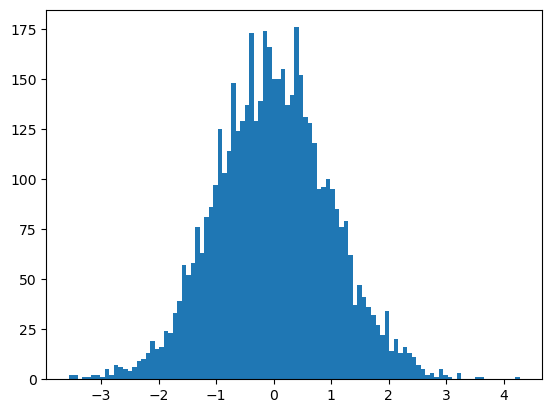

In [26]:
# Explain np.random.standard_normal
sample = np.random.standard_normal(5000)
plt.hist(sample,bins=100)

In [27]:
print(np.mean(sample))
print(np.std(sample))

-0.009599334463717411
0.9984144139499245


In [28]:
# Create a function to calculate the returns of the investment
def VaR(pv, rfr, vol, t, simulations):
    end_value = pv * np.exp((rfr - .5 * vol ** 2) * t + np.random.standard_normal(
        simulations) * vol * np.sqrt(t))
    returns = end_value - pv
    return returns

# Apply the VaR function to simulate the returns
returns_MSFT = VaR(value_MSFT, rfr_MSFT, vol_MSFT, t_MSFT, simulations)

### Quantifications - Identify VaR at 90%, 95%, and 99% Confidence Level

In [29]:
# Explain string formatting
# Print: VaR at x% confidence level: $y.

x = 0.9
y = 3455.248
print("VaR at {:.0%} confidence level: ${:,.0f}".format(x, y))

VaR at 90% confidence level: $3,455


VaR at 90% confidence level: $-30,940
VaR at 95% confidence level: $-39,243
VaR at 99% confidence level: $-54,028


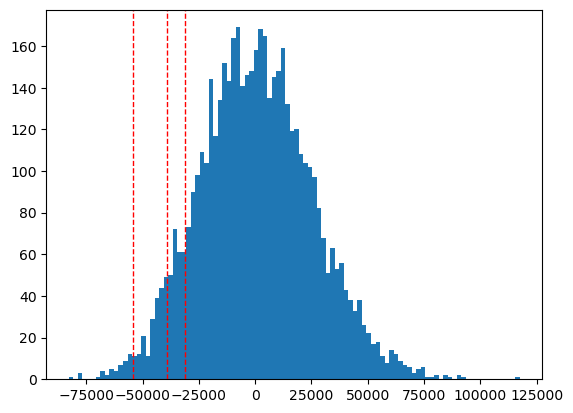

In [30]:
# Plot the returns
plt.hist(returns_MSFT, bins=100);

# Show VaR at 90%, 95%, and 99% confidence level
percentiles = [10,5,1]

for i in percentiles:
    confidence = (100-i)/100
    value = np.percentile(returns_MSFT, i)
    print("VaR at {:.0%} confidence level: ${:,.0f}".format(confidence, value))
    plt.axvline(value, color = 'red', linestyle='dashed', linewidth=1)